# Exploratory Data Analysis

In [5]:
# Importing libraries

import numpy as np
import pandas as pd

# Load connectivity matrices and phenotypic data
conn = np.load('../data/conn (1).npy')
df = pd.read_csv('../data/pheno_data.csv')

# Confirm shapes and age range
print(f'Connectivity shape: {conn.shape}')
print(f'Pheno data shape: {df.shape}')
print(f'Age range: {df.AGE_AT_SCAN.min():.1f} - {df.AGE_AT_SCAN.max():.1f} years')

Connectivity shape: (468, 200, 200)
Pheno data shape: (468, 104)
Age range: 6.5 - 56.2 years


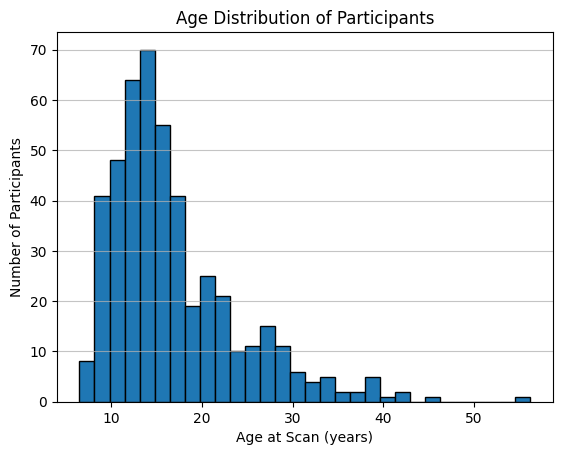

In [6]:
# Visualizing age distribution

import matplotlib.pyplot as plt

plt.hist(df['AGE_AT_SCAN'], bins = 30, edgecolor = 'black')
plt.title('Age Distribution of Participants')
plt.xlabel('Age at Scan (years)')
plt.ylabel('Number of Participants')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()



In [7]:
# Getting summary statistics of age distribution

age_stats = df['AGE_AT_SCAN'].describe()
print(age_stats)

count    468.000000
mean      16.839033
std        7.242266
min        6.470000
25%       12.032500
50%       14.800000
75%       20.000000
max       56.200000
Name: AGE_AT_SCAN, dtype: float64


In [8]:
# Inspect a single connectivity matrix
sample = conn[0]

print(f'Shape: {sample.shape}')
print(f'Value range: {sample.min():.3f} to {sample.max():.3f}')
print(f'Symmetric: {np.allclose(sample, sample.T)}')
print(f'Diagonal values (first 5): {sample.diagonal()[:5]}')

Shape: (200, 200)
Value range: -0.367 to 1.000
Symmetric: True
Diagonal values (first 5): [1. 1. 1. 1. 1.]


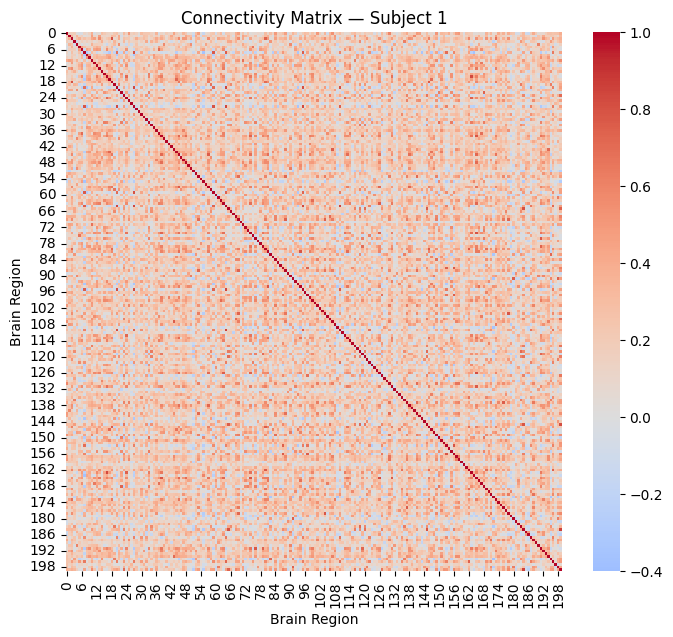

In [9]:
# Visualize one subject's connectivity matrix
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.heatmap(sample, cmap='coolwarm', center=0, vmin=-0.4, vmax=1.0)
plt.title('Connectivity Matrix — Subject 1')
plt.xlabel('Brain Region')
plt.ylabel('Brain Region')
plt.show()

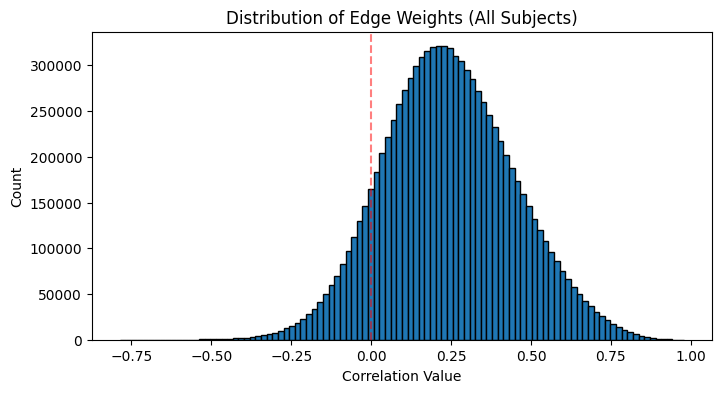

Mean: nan
Std: nan
% negative edges: 11.3%


In [10]:
# Distribution of edge weights (upper triangle only, excluding diagonal)
upper_tri = conn[:, np.triu_indices(200, k=1)[0], np.triu_indices(200, k=1)[1]]

plt.figure(figsize=(8, 4))
plt.hist(upper_tri.flatten(), bins=100, edgecolor='black')
plt.title('Distribution of Edge Weights (All Subjects)')
plt.xlabel('Correlation Value')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

print(f'Mean: {upper_tri.mean():.3f}')
print(f'Std: {upper_tri.std():.3f}')
print(f'% negative edges: {(upper_tri < 0).mean()*100:.1f}%')

In [11]:
# Check for subjects with NaN in connectivity matrices
bad_indices = []
for i in range(conn.shape[0]):
    if np.isnan(conn[i]).any():
        bad_indices.append(i)

print(f'Subjects with NaN: {bad_indices}')
print(f'Removing {len(bad_indices)} subjects, keeping {conn.shape[0] - len(bad_indices)}')

# Remove bad subjects
good_indices = [i for i in range(conn.shape[0]) if i not in bad_indices]
conn_clean = conn[good_indices]
df_clean = df.iloc[good_indices].reset_index(drop=True)

# Save clean data
np.save('../data/conn_clean.npy', conn_clean)
df_clean.to_csv('../data/pheno_data_clean.csv', index=False)

print(f'Saved: conn_clean.npy {conn_clean.shape}, pheno_data_clean.csv {df_clean.shape}')

Subjects with NaN: [15, 55, 67, 72, 73, 206, 282, 334, 449, 456]
Removing 10 subjects, keeping 458
Saved: conn_clean.npy (458, 200, 200), pheno_data_clean.csv (458, 104)


## EDA Conclusions

### Age Distribution
The age distribution is noticeably skewed toward younger participants, with a mean of 16.84 years and the bulk of subjects falling between 8 and 18. There are a few older outliers extending up to 56, but these are sparse. This imbalance means the model will most likely perform better on younger ages since it has far more examples to learn from. Should we address this later through oversampling or a weighted loss function?

### Connectivity Matrices
Each subject's data is a 200x200 symmetric correlation matrix representing functional connectivity between brain regions. The diagonal is all 1s (self-correlation) and values range from roughly -0.367 to 1.0. Symmetry confirms these are undirected graphs, so we only need the upper triangle when building edge lists. The diagonal will be dropped since self-loops aren't informative here. We'll also need to make a decision about negative values, whether to discard them, take absolute values, or keep them as-is.

### Edge Weights
The edge weight distribution across all subjects is approximately normal, centered around 0.2–0.3, with a relatively small proportion of negative edges. Since a fully connected 200-node graph produces nearly 20,000 edges per subject, thresholding may be necessary to reduce noise and computational cost. Based on the distribution, a cutoff in the 0.3–0.4 range seems reasonable as a starting point, though this will be tuned during graph construction.

### Takeaways
The data is clean and well-structured with no major issues. The key decisions going into graph construction are where to set the edge threshold, how to handle negative correlations, and what to use as node features. The age imbalance is also worth keeping in mind as we move into model training.
